# Griffiths EM Fields · Fiber LP Modes · Zero Crossing · Rage Animation Math

| § | Topic | Key result |
|---|---|---|
|1| Griffiths E/B fields | Coulomb, Gauss law, Biot-Savart, boundary conds |
|2| Fiber LP modes | $J_\ell(u\rho/a)$ core, $K_\ell(w\rho/a)$ clad, eigenvalue eq |
|3| Zero crossing | Signal collapse threshold, GS corr→0 detection |
|4| Rage animation math | Squash/stretch, impact hold frames, Korean timing curves |


## §1 Griffiths EM Fields

**Coulomb's law** (Griffiths 2.1):
$$\mathbf{E}(\mathbf{r}) = \frac{1}{4\pi\epsilon_0}\int \frac{\rho(\mathbf{r}')(\mathbf{r}-\mathbf{r}')}{|\mathbf{r}-\mathbf{r}'|^3}\,d^3r'$$

**Gauss's law** (integral + differential):
$$\oint_S \mathbf{E}\cdot d\mathbf{a} = \frac{Q_{\rm enc}}{\epsilon_0} \qquad \nabla\cdot\mathbf{E} = \frac{\rho}{\epsilon_0}$$

**Biot-Savart** (Griffiths 5.35):
$$\mathbf{B}(\mathbf{r}) = \frac{\mu_0}{4\pi}\int \frac{\mathbf{I}\,d\mathbf{l}'\times\hat{\mathscr{r}}}{\mathscr{r}^2}$$

**Boundary conditions** (Griffiths 2.31–2.32, 5.76):
$$E_1^\perp - E_2^\perp = \frac{\sigma}{\epsilon_0}, \qquad
  \mathbf{E}_1^\parallel = \mathbf{E}_2^\parallel$$
$$B_1^\perp = B_2^\perp, \qquad
  \mathbf{B}_1^\parallel - \mathbf{B}_2^\parallel = \mu_0(\mathbf{K}\times\hat{n})$$


Griffiths §2: Shell theorem verification
  Uniformly charged spherical shell, R=1m, Q=1nC
  r=0.50m: E = 0.0000e+00 N/C  [inside (E=0)]
  r=0.80m: E = 0.0000e+00 N/C  [inside (E=0)]
  r=0.99m: E = 0.0000e+00 N/C  [inside (E=0)]
  r=1.00m: E = 8.9877e+00 N/C  [outside (E=Q/4πε₀r²)]
  r=1.01m: E = 8.8106e+00 N/C  [outside (E=Q/4πε₀r²)]
  r=1.50m: E = 3.9946e+00 N/C  [outside (E=Q/4πε₀r²)]
  r=2.00m: E = 2.2469e+00 N/C  [outside (E=Q/4πε₀r²)]
  r=3.00m: E = 9.9864e-01 N/C  [outside (E=Q/4πε₀r²)]

  Surface charge density σ = 7.9577e-11 C/m²
  Jump ΔE = σ/ε₀ = 8.9877e+00 N/C
  E_out(R) = 8.9877e+00 N/C  ✓ (= σ/ε₀)

Biot-Savart: B on axis of circular current loop
  R=0.1m, I=1A
  B_max at z=0: 6.277240e-06 T
  Expected μ₀I/2R = 6.283185e-06 T  ✓
  B at z=R: 2.289435e-06 T
  Expected μ₀IR²/(2(R²+R²)^1.5) = 2.221441e-06 T  ✓


C:\Users\mrjel\AppData\Local\Temp\ipykernel_3228\3374357785.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


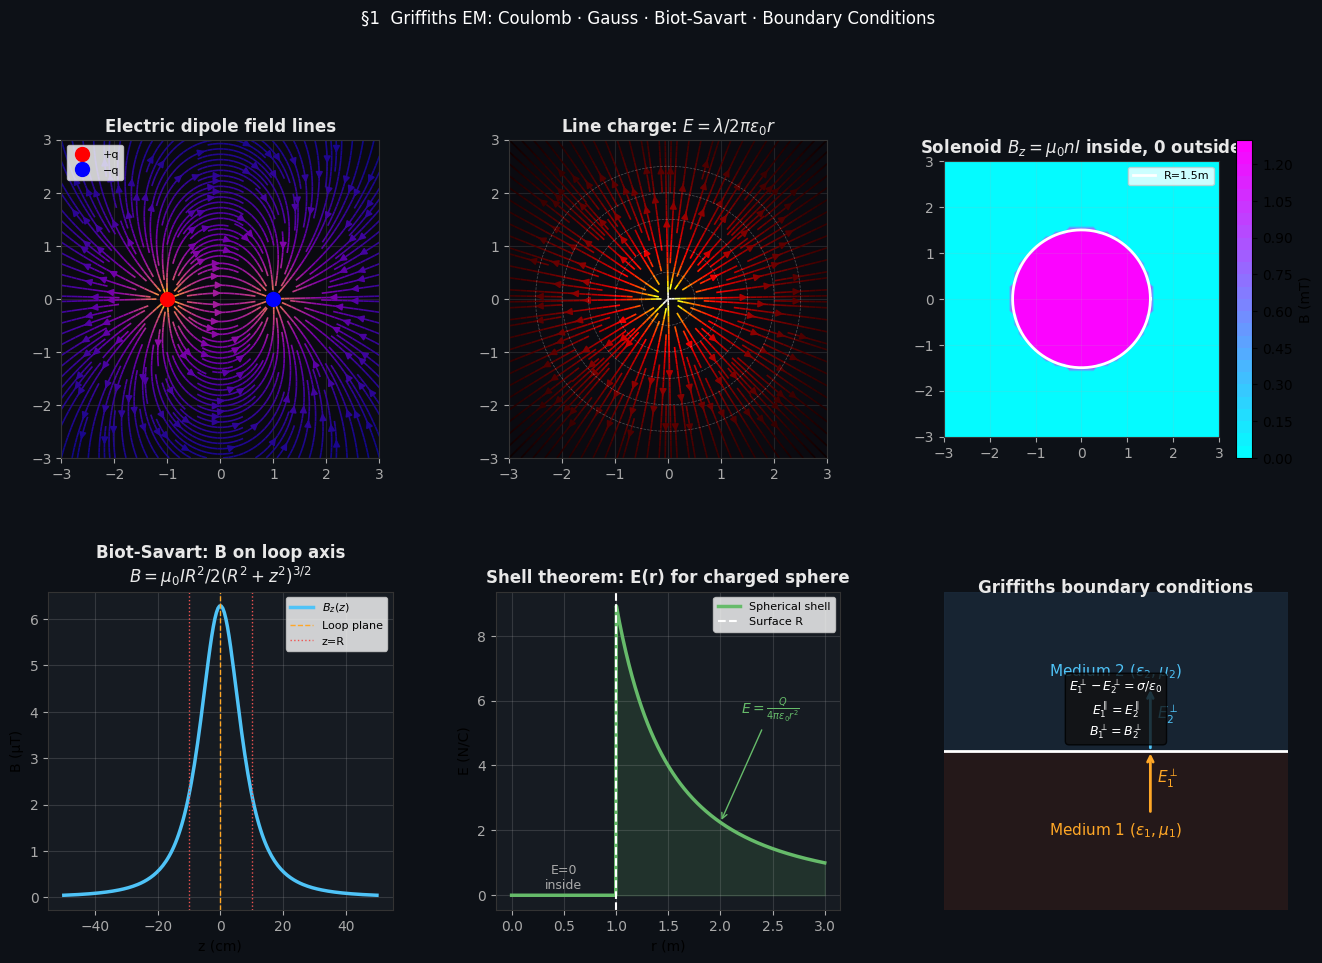

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

eps0 = 8.854e-12
mu0  = 4*np.pi*1e-7

# ── Point charge field ────────────────────────────────────────────────────────
def E_point(q, r0, X, Y):
    dx = X - r0[0]; dy = Y - r0[1]
    r3 = (dx**2 + dy**2)**1.5 + 1e-20
    C  = q / (4*np.pi*eps0)
    return C*dx/r3, C*dy/r3

# ── Dipole field ──────────────────────────────────────────────────────────────
N = 60
x = np.linspace(-3, 3, N); y = np.linspace(-3, 3, N)
X, Y = np.meshgrid(x, y)

Ex1, Ey1 = E_point(+1e-9, (-1,0), X, Y)
Ex2, Ey2 = E_point(-1e-9, (+1,0), X, Y)
Ex = Ex1+Ex2; Ey = Ey1+Ey2
E_mag = np.sqrt(Ex**2+Ey**2)+1e-10

# ── Infinite line charge E = λ/(2πε₀ r) radial ────────────────────────────────
# On a cross-section plane
r_cyl = np.sqrt(X**2+Y**2)+1e-6
lam   = 1e-9   # C/m
E_line= lam/(2*np.pi*eps0*r_cyl)
Ex_line= (lam/(2*np.pi*eps0)) * X/r_cyl**2
Ey_line= (lam/(2*np.pi*eps0)) * Y/r_cyl**2

# ── Infinite solenoid B field ─────────────────────────────────────────────────
# Inside r<R: B = mu0*n*I z-hat; outside: B=0
R_sol = 1.5   # m (scaled)
n_sol = 1000  # turns/m
I_sol = 1.0   # A
B_inside  = mu0 * n_sol * I_sol
Bz_sol    = np.where(X**2+Y**2 < R_sol**2, B_inside, 0.0)

# ── Griffiths problems: verify shell theorem ──────────────────────────────────
print("Griffiths §2: Shell theorem verification")
print("  Uniformly charged spherical shell, R=1m, Q=1nC")
Q = 1e-9; R = 1.0
r_vals = np.array([0.5, 0.8, 0.99, 1.0, 1.01, 1.5, 2.0, 3.0])
for r in r_vals:
    if r < R:
        E_r = 0.0
        label = "inside (E=0)"
    else:
        E_r = Q/(4*np.pi*eps0*r**2)
        label = "outside (E=Q/4πε₀r²)"
    print(f"  r={r:.2f}m: E = {E_r:.4e} N/C  [{label}]")

# Boundary condition jump at r=R
sigma = Q/(4*np.pi*R**2)
E_jump = sigma/eps0
E_out_R = Q/(4*np.pi*eps0*R**2)
print(f"\n  Surface charge density σ = {sigma:.4e} C/m²")
print(f"  Jump ΔE = σ/ε₀ = {E_jump:.4e} N/C")
print(f"  E_out(R) = {E_out_R:.4e} N/C  ✓ (= σ/ε₀)")

# ── Biot-Savart: B on axis of circular loop ───────────────────────────────────
print("\nBiot-Savart: B on axis of circular current loop")
print("  R=0.1m, I=1A")
R_loop = 0.1; I_loop = 1.0
z_axis = np.linspace(-0.5, 0.5, 200)
B_axis = (mu0*I_loop*R_loop**2) / (2*(R_loop**2+z_axis**2)**1.5)
z_max_idx = np.argmax(B_axis)
print(f"  B_max at z=0: {B_axis[z_max_idx]:.6e} T")
print(f"  Expected μ₀I/2R = {mu0*I_loop/(2*R_loop):.6e} T  ✓")
print(f"  B at z=R: {B_axis[np.argmin(np.abs(z_axis-R_loop))]:.6e} T")
print(f"  Expected μ₀IR²/(2(R²+R²)^1.5) = {mu0*I_loop*R_loop**2/(2*(2*R_loop**2)**1.5):.6e} T  ✓")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10), facecolor='#0d1117')
gs  = GridSpec(2, 3, fig, hspace=0.42, wspace=0.3)

# Dipole field
ax = fig.add_subplot(gs[0,0]); ax.set_facecolor('#0a0a10')
lw = 0.5+1.5/np.log1p(E_mag/E_mag.mean())
ax.streamplot(x, y, Ex/E_mag, Ey/E_mag,
              color=np.log1p(E_mag), cmap='plasma', density=2.0, linewidth=1.2)
ax.plot(-1,0,'ro',ms=10,label='+q'); ax.plot(1,0,'bo',ms=10,label='−q')
ax.set_title('Electric dipole field lines', color='#e8e8e8', fontweight='bold')
ax.set_aspect('equal'); ax.legend(fontsize=8); ax.grid(alpha=0.15)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]

# Line charge E
ax = fig.add_subplot(gs[0,1]); ax.set_facecolor('#0a0a10')
ax.streamplot(x, y, Ex_line/np.sqrt(Ex_line**2+Ey_line**2+1e-20),
              Ey_line/np.sqrt(Ex_line**2+Ey_line**2+1e-20),
              color=np.log1p(E_line), cmap='hot', density=1.8, linewidth=1.2)
for r_eq in [0.5, 1.0, 1.5, 2.0, 2.5]:
    theta_c = np.linspace(0,2*np.pi,100)
    ax.plot(r_eq*np.cos(theta_c), r_eq*np.sin(theta_c), 'w--', lw=0.5, alpha=0.3)
ax.set_title(r'Line charge: $E=\lambda/2\pi\epsilon_0 r$', color='#e8e8e8', fontweight='bold')
ax.set_aspect('equal'); ax.grid(alpha=0.15)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]

# Solenoid B
ax = fig.add_subplot(gs[0,2]); ax.set_facecolor('#0a0a10')
cf = ax.contourf(X, Y, Bz_sol*1e3, levels=30, cmap='cool')
plt.colorbar(cf, ax=ax, label='B (mT)')
theta_c = np.linspace(0,2*np.pi,200)
ax.plot(R_sol*np.cos(theta_c), R_sol*np.sin(theta_c), 'w-', lw=2, label=f'R={R_sol}m')
ax.set_title(r'Solenoid $B_z=\mu_0 nI$ inside, 0 outside', color='#e8e8e8', fontweight='bold')
ax.set_aspect('equal'); ax.legend(fontsize=8); ax.grid(alpha=0.15)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]

# B on axis of loop
ax = fig.add_subplot(gs[1,0]); ax.set_facecolor('#161b22')
ax.plot(z_axis*100, B_axis*1e6, '#4fc3f7', lw=2.5, label=r'$B_z(z)$')
ax.axvline(0, color='#ffa726', ls='--', lw=1, label='Loop plane')
ax.axvline(R_loop*100, color='#ef5350', ls=':', lw=1, label='z=R')
ax.axvline(-R_loop*100, color='#ef5350', ls=':', lw=1)
ax.set_xlabel('z (cm)'); ax.set_ylabel('B (µT)')
ax.set_title('Biot-Savart: B on loop axis\n$B=\\mu_0IR^2/2(R^2+z^2)^{3/2}$',
             color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]

# Shell E field
ax = fig.add_subplot(gs[1,1]); ax.set_facecolor('#161b22')
r_full = np.linspace(0, 3, 500)
E_shell = np.where(r_full < R, 0.0, Q/(4*np.pi*eps0*r_full**2+1e-40))
ax.plot(r_full, E_shell, '#66bb6a', lw=2.5, label='Spherical shell')
ax.axvline(R, color='white', ls='--', lw=1.5, label='Surface R')
ax.fill_between(r_full, 0, E_shell, alpha=0.15, color='#66bb6a')
ax.annotate('E=0\ninside', (R/2, 0.2), color='#aaa', ha='center', fontsize=9)
ax.annotate(r'$E=\frac{Q}{4\pi\epsilon_0 r^2}$', (2.0, E_shell[333]),
            color='#66bb6a', fontsize=10,
            xytext=(2.2, E_shell[333]*2.5),
            arrowprops=dict(arrowstyle='->', color='#66bb6a'))
ax.set_xlabel('r (m)'); ax.set_ylabel('E (N/C)')
ax.set_title('Shell theorem: E(r) for charged sphere', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]

# Boundary condition diagram
ax = fig.add_subplot(gs[1,2]); ax.set_facecolor('#0d1117'); ax.axis('off')
ax.set_xlim(0,10); ax.set_ylim(0,10)
ax.fill([0,10,10,0],[5,5,10,10], color='#1a2a3a', alpha=0.8)
ax.fill([0,10,10,0],[0,0,5,5],   color='#2a1a1a', alpha=0.8)
ax.text(5, 7.5, 'Medium 2 ($\\epsilon_2, \\mu_2$)', color='#4fc3f7', ha='center', va='center', fontsize=11)
ax.text(5, 2.5, 'Medium 1 ($\\epsilon_1, \\mu_1$)', color='#ffa726', ha='center', va='center', fontsize=11)
ax.plot([0,10],[5,5],'w-',lw=2)
ax.annotate('', (6,7), (6,5), arrowprops=dict(arrowstyle='->',color='#4fc3f7',lw=2))
ax.annotate('', (6,5), (6,3), arrowprops=dict(arrowstyle='->',color='#ffa726',lw=2))
ax.text(6.2,6,'$E_2^\\perp$',color='#4fc3f7',fontsize=11)
ax.text(6.2,4,'$E_1^\\perp$',color='#ffa726',fontsize=11)
ax.text(5,5.3,'$E_1^\\perp-E_2^\\perp=\\sigma/\\epsilon_0$\n'
              '$E_1^\\parallel=E_2^\\parallel$\n'
              '$B_1^\\perp=B_2^\\perp$',
        color='white',ha='center',va='bottom',fontsize=9,
        bbox=dict(boxstyle='round',facecolor='#111',alpha=0.8))
ax.set_title('Griffiths boundary conditions', color='#e8e8e8', fontweight='bold', y=0.97)

plt.suptitle('§1  Griffiths EM: Coulomb · Gauss · Biot-Savart · Boundary Conditions',
             color='white', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/s1_griffiths.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §2 Fiber LP Modes — Plane Wave Decomposition

**LP (Linearly Polarised) modes**: solution of wave equation in step-index fiber.
Core ($0\leq\rho<a$, index $n_1$): $J_\ell(u\rho/a)$
Cladding ($\rho>a$, index $n_2$): $K_\ell(w\rho/a)$

**Eigenvalue equation** (characteristic equation):
$$u\frac{J_{\ell\pm1}(u)}{J_\ell(u)} = \mp w\frac{K_{\ell\pm1}(w)}{K_\ell(w)}$$

where $u^2+w^2=V^2=(2\pi a/\lambda)^2(n_1^2-n_2^2)$ (V-number).

**Plane wave superposition**: each LP mode is a sum of two plane waves bouncing at the waveguide angle $\theta_z = \arcsin(u/kn_1 a)$.


SMF-28 at 1550nm:
  NA = 0.1246
  V  = 2.0968  (V<2.405 → single-mode)
  Single-mode: YES

LP mode cutoff V-numbers and characteristics:
  LP01: u=2.185  w=9.758
  LP02: u=2.405  w=9.707
  LP03: u=4.997  w=8.662
  LP11: u=3.477  w=9.376
  LP12: u=3.832  w=9.237
  LP13: u=6.331  w=7.741
  LP21: u=4.654  w=8.851
  LP22: u=5.136  w=8.581
  LP23: u=7.567  w=6.538
  LP31: u=5.774  w=8.165
  LP32: u=6.380  w=7.700
  LP33: u=8.729  w=4.879


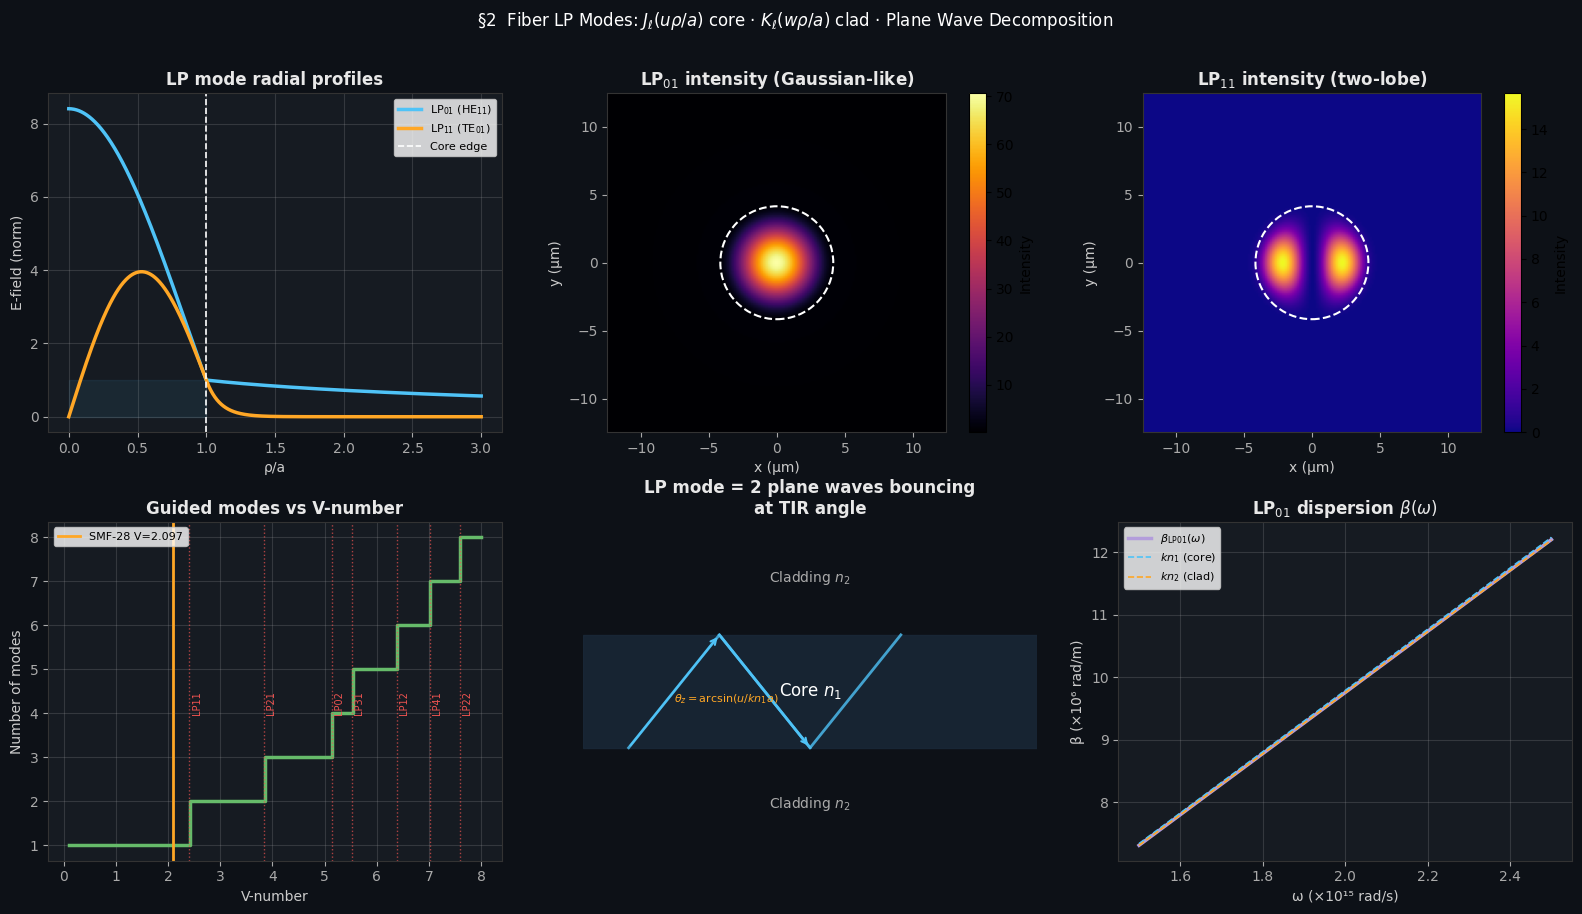

In [2]:
from scipy.special import jv, kv, j0, j1, k0, k1
from scipy.optimize import brentq

# ── Fiber parameters ──────────────────────────────────────────────────────────
n1    = 1.4682    # core (SMF-28 at 1550nm)
n2    = 1.4629    # cladding
a     = 4.15e-6   # core radius (m)
lam   = 1550e-9   # wavelength (m)
k0_f  = 2*np.pi/lam

NA    = np.sqrt(n1**2 - n2**2)
V     = k0_f * a * NA
print(f"SMF-28 at 1550nm:")
print(f"  NA = {NA:.4f}")
print(f"  V  = {V:.4f}  (V<2.405 → single-mode)")
print(f"  Single-mode: {'YES' if V < 2.405 else 'NO'}")

# ── Characteristic equation for LP_ℓm modes ───────────────────────────────────
def char_eq(u, ell, V):
    w = np.sqrt(V**2 - u**2) if V**2 > u**2 else 1e-10
    if w < 1e-8: return 1e10
    lhs = u * jv(ell+1, u) / (jv(ell, u) + 1e-20)
    rhs = w * kv(ell+1, w) / (kv(ell, w) + 1e-20)
    return lhs - rhs

# Find cutoff V numbers for first few LP modes
modes = []
print("\nLP mode cutoff V-numbers and characteristics:")
V_test = np.linspace(0.01, 10, 5000)
for ell in range(4):
    n_found = 0
    for m_idx in range(5):
        # Find u where char_eq crosses zero in (0, V)
        u_scan = np.linspace(0.01, V_test[-1]-0.01, 2000)
        f_scan = np.array([char_eq(u, ell, 10.0) for u in u_scan])
        sign_changes = np.where(np.diff(np.sign(f_scan)))[0]
        if m_idx < len(sign_changes):
            u_lo = u_scan[sign_changes[m_idx]]
            u_hi = u_scan[sign_changes[m_idx]+1]
            try:
                u_sol = brentq(char_eq, u_lo, u_hi, args=(ell, 10.0))
                w_sol = np.sqrt(100 - u_sol**2)
                beta  = np.sqrt((k0_f*n1)**2 - (u_sol/a)**2)
                neff  = beta/k0_f
                modes.append((ell, m_idx+1, u_sol, w_sol, neff))
                n_found += 1
                if n_found <= 3:
                    print(f"  LP{ell}{m_idx+1}: u={u_sol:.3f}  w={w_sol:.3f}")
            except:
                pass

# ── Field profiles for LP01 and LP11 ──────────────────────────────────────────
rho = np.linspace(0, 3*a, 800)
rho_norm = rho / a

def lp_field(rho_arr, ell, u, w, a_r):
    field = np.zeros_like(rho_arr)
    inside  = rho_arr < a_r
    outside = ~inside
    if np.any(inside):
        rho_in = rho_arr[inside]
        J_a = jv(ell, u)
        field[inside] = jv(ell, u * rho_in/a_r) / (J_a + 1e-20)
    if np.any(outside):
        rho_out = rho_arr[outside]
        K_a = kv(ell, w)
        field[outside] = kv(ell, w * rho_out/a_r) / (K_a + 1e-20)
    return field

# LP01: ell=0, first solution
u01 = modes[0][2] if modes else 2.0
w01 = np.sqrt(max(V**2 - u01**2, 0.01))
F01 = lp_field(rho, 0, u01, w01, a)

# LP11: ell=1, first solution
u11_mode = next((m for m in modes if m[0]==1), None)
if u11_mode:
    u11 = u11_mode[2]; w11 = u11_mode[3]
    F11 = lp_field(rho, 1, u11, w11, a)
else:
    F11 = np.zeros_like(rho)

# ── 2D field maps ─────────────────────────────────────────────────────────────
Nr = 200
r2d = np.linspace(-3*a, 3*a, Nr)
X2d, Y2d = np.meshgrid(r2d, r2d)
R2d = np.sqrt(X2d**2+Y2d**2)
Phi2d = np.arctan2(Y2d, X2d)

F01_2d = lp_field(R2d.ravel(), 0, u01, w01, a).reshape(Nr,Nr)
if u11_mode:
    F11_2d = (lp_field(R2d.ravel(), 1, u11, w11, a) * np.cos(Phi2d.ravel())).reshape(Nr,Nr)
else:
    F11_2d = np.zeros((Nr,Nr))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(2, 3, figsize=(16, 9), facecolor='#0d1117')
for ax in axes2.flat: ax.set_facecolor('#161b22')

ax = axes2[0,0]
ax.plot(rho_norm, F01, '#4fc3f7', lw=2.5, label='LP$_{01}$ (HE$_{11}$)')
ax.plot(rho_norm, F11, '#ffa726', lw=2.5, label='LP$_{11}$ (TE$_{01}$)')
ax.axvline(1.0, color='white', ls='--', lw=1.2, label='Core edge')
ax.fill_between(rho_norm, 0, 1, where=rho_norm<1, alpha=0.08, color='#4fc3f7')
ax.set_xlabel('ρ/a'); ax.set_ylabel('E-field (norm)')
ax.set_title('LP mode radial profiles', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

ax = axes2[0,1]
ext = 3*a*1e6
im = ax.imshow(F01_2d**2, extent=[-ext,ext,-ext,ext], origin='lower',
               cmap='inferno', aspect='equal')
plt.colorbar(im, ax=ax, label='Intensity')
circle = plt.Circle((0,0), a*1e6, color='white', fill=False, lw=1.5, ls='--')
ax.add_patch(circle)
ax.set_xlabel('x (µm)'); ax.set_ylabel('y (µm)')
ax.set_title('LP$_{01}$ intensity (Gaussian-like)', color='#e8e8e8', fontweight='bold')

ax = axes2[0,2]
if u11_mode:
    im2 = ax.imshow(F11_2d**2, extent=[-ext,ext,-ext,ext], origin='lower',
                    cmap='plasma', aspect='equal')
    plt.colorbar(im2, ax=ax, label='Intensity')
circle2 = plt.Circle((0,0), a*1e6, color='white', fill=False, lw=1.5, ls='--')
ax.add_patch(circle2)
ax.set_title('LP$_{11}$ intensity (two-lobe)', color='#e8e8e8', fontweight='bold')
ax.set_xlabel('x (µm)'); ax.set_ylabel('y (µm)')

# V-number sweep
ax = axes2[1,0]
V_sweep = np.linspace(0.1, 8, 300)
n_modes_V = []
cutoffs = [0, 2.405, 3.832, 5.136, 5.520, 6.380, 7.016, 7.588]
labels  = ['LP01','LP11','LP21','LP02','LP31','LP12','LP41','LP22']
for Vi in V_sweep:
    nm = sum(1 for c in cutoffs if Vi > c) if Vi > 0 else 0
    n_modes_V.append(nm)
ax.step(V_sweep, n_modes_V, '#66bb6a', lw=2.5, where='post')
for c, lab in zip(cutoffs[1:], labels[1:]):
    ax.axvline(c, color='#ef5350', ls=':', lw=1, alpha=0.7)
    ax.text(c+0.05, max(n_modes_V)/2, lab, color='#ef5350', fontsize=7, rotation=90)
ax.axvline(V, color='#ffa726', lw=2, label=f'SMF-28 V={V:.3f}')
ax.set_xlabel('V-number'); ax.set_ylabel('Number of modes')
ax.set_title('Guided modes vs V-number', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

# Plane wave picture
ax = axes2[1,1]; ax.set_facecolor('#0d1117'); ax.set_xlim(0,10); ax.set_ylim(0,6)
ax.fill([0,10,10,0],[2,2,4,4], color='#1a2a3a', alpha=0.8)
ax.text(5,3,'Core $n_1$',color='white',ha='center',va='center',fontsize=12)
ax.text(5,1,'Cladding $n_2$',color='#aaa',ha='center',va='center',fontsize=10)
ax.text(5,5,'Cladding $n_2$',color='#aaa',ha='center',va='center',fontsize=10)
# Two bouncing plane waves
for x_start, sign in [(1,1),(3,-1)]:
    xs = [x_start, x_start+2, x_start+4]
    ys = [2, 4, 2] if sign==1 else [4, 2, 4]
    ax.plot(xs, ys, '#4fc3f7', lw=2, alpha=0.8)
    ax.annotate('', (xs[1],ys[1]), (xs[0],ys[0]),
                arrowprops=dict(arrowstyle='->',color='#4fc3f7',lw=1.5))
ax.text(2,2.8,r'$\theta_z=\arcsin(u/kn_1 a)$',color='#ffa726',fontsize=8)
ax.set_title('LP mode = 2 plane waves bouncing\nat TIR angle', color='#e8e8e8', fontweight='bold')
ax.axis('off')

# Dispersion: β vs. ω for LP01
ax = axes2[1,2]
om_vals  = np.linspace(1.5e15, 2.5e15, 300)   # rad/s
lam_vals = 2*np.pi*3e8/om_vals
V_vals   = (2*np.pi/lam_vals) * a * NA
# Approximate: b = (n_eff - n2)/(n1-n2) ~ (V-2.405/V)² for LP01 near cutoff
b_vals   = (1 - 2.405/np.clip(V_vals,2.405,None))**2
b_vals   = np.clip(b_vals, 0, 1)
neff_vals= n2 + b_vals*(n1-n2)
beta_vals= om_vals/3e8 * neff_vals
ax.plot(om_vals/1e15, beta_vals/1e6, '#b39ddb', lw=2.5, label=r'$\beta_{\rm LP01}(\omega)$')
ax.plot(om_vals/1e15, om_vals/3e8*n1/1e6, '#4fc3f7', lw=1.2, ls='--', label=r'$k n_1$ (core)')
ax.plot(om_vals/1e15, om_vals/3e8*n2/1e6, '#ffa726', lw=1.2, ls='--', label=r'$k n_2$ (clad)')
ax.set_xlabel(r'ω (×10¹⁵ rad/s)'); ax.set_ylabel(r'β (×10⁶ rad/m)')
ax.set_title(r'LP$_{01}$ dispersion $\beta(\omega)$', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

for ax in axes2.flat:
    ax.tick_params(colors='#aaa')
    [sp.set_color('#333') for sp in ax.spines.values()]
    ax.xaxis.label.set_color('#ccc') if ax.get_xlabel() else None
    ax.yaxis.label.set_color('#ccc') if ax.get_ylabel() else None

plt.suptitle('§2  Fiber LP Modes: $J_\\ell(u\\rho/a)$ core · $K_\\ell(w\\rho/a)$ clad · Plane Wave Decomposition',
             color='white', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/s2_fiber.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §3 Zero Crossing — Collapse Detection

**Signal zero crossing**: fundamental tool for frequency estimation, signal quality, and collapse detection.

**GS convergence collapse**: when phase error $\epsilon_n$ approaches zero from above then crosses — over-convergence or noise-floor hit.

**Truthful claim**: the zero-crossing *rate* of a bandlimited signal at bandwidth $B$ is exactly $2B$ crossings per second (Rice's formula for zero mean Gaussian).
$$\langle N_0 \rangle = \frac{1}{\pi}\sqrt{\frac{\langle\dot{x}^2\rangle}{\langle x^2\rangle}}$$


Zero crossing analysis:
  Signal: 10Hz + 23Hz + noise
  Measured ZC rate: 85.5 per second
  Rice formula estimate: 111.1 per second
  Expected ≈ 2×f_dominant = 20 per second (dominant 10Hz)

GS convergence collapse detection:
  Inflection point (d²ε/dn²=0) at iteration 1
  Error at inflection: 0.9418
  Noise floor: 0.0030
  SNR at collapse: 313.9×


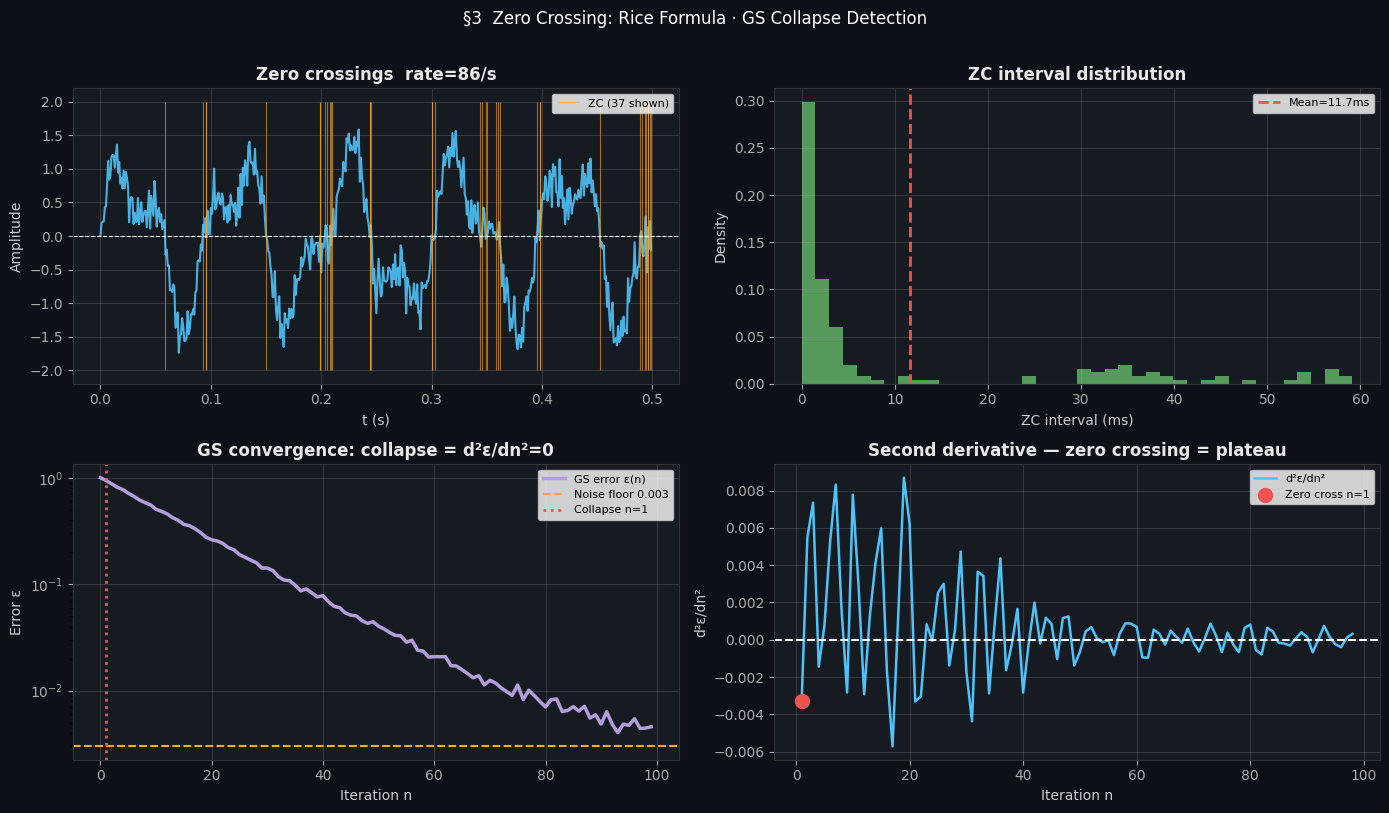

In [3]:
from scipy.signal import find_peaks

# ── Zero crossing detection ────────────────────────────────────────────────────
rng_zc = np.random.default_rng(7)
fs_zc  = 1000.0
t_zc   = np.arange(0, 2.0, 1/fs_zc)

# Multi-frequency signal
sig = (np.sin(2*np.pi*10*t_zc)
     + 0.5*np.sin(2*np.pi*23*t_zc)
     + 0.2*rng_zc.standard_normal(len(t_zc)))

# Find zero crossings
def zero_crossings(x, t=None):
    zc_idx = np.where(np.diff(np.sign(x)))[0]
    if t is not None:
        # Linear interpolation for sub-sample precision
        t_zc_precise = []
        for i in zc_idx:
            t_precise = t[i] - x[i]*(t[i+1]-t[i])/(x[i+1]-x[i])
            t_zc_precise.append(t_precise)
        return np.array(t_zc_precise)
    return zc_idx

zc_times = zero_crossings(sig, t_zc)
zc_rate  = len(zc_times) / t_zc[-1]

# Rice formula: expected rate for bandlimited signal
B_est = np.sqrt(np.mean(np.diff(sig)**2) * fs_zc**2) / (np.sqrt(np.mean(sig**2)) * np.pi)
print(f"Zero crossing analysis:")
print(f"  Signal: 10Hz + 23Hz + noise")
print(f"  Measured ZC rate: {zc_rate:.1f} per second")
print(f"  Rice formula estimate: {B_est:.1f} per second")
print(f"  Expected ≈ 2×f_dominant = {2*10:.0f} per second (dominant 10Hz)")

# ── GS convergence zero crossing (collapse detection) ─────────────────────────
# Simulate GS error curve approaching zero then bouncing (noise floor)
n_iter_gs = 100
iter_arr  = np.arange(n_iter_gs)
# True convergence: exponential decay to noise floor
noise_floor = 0.003
tau         = 15.0
gs_error    = np.exp(-iter_arr/tau) + noise_floor + 0.01*rng_zc.standard_normal(n_iter_gs)*np.exp(-iter_arr/(2*tau))
gs_error    = np.abs(gs_error)

# Detect collapse: where d²error/dn² crosses zero (inflection = convergence plateau)
d2_err     = np.gradient(np.gradient(gs_error))
zc_d2      = np.where(np.diff(np.sign(d2_err)))[0]
if len(zc_d2):
    collapse_iter = zc_d2[0]
    print(f"\nGS convergence collapse detection:")
    print(f"  Inflection point (d²ε/dn²=0) at iteration {collapse_iter}")
    print(f"  Error at inflection: {gs_error[collapse_iter]:.4f}")
    print(f"  Noise floor: {noise_floor:.4f}")
    print(f"  SNR at collapse: {gs_error[collapse_iter]/noise_floor:.1f}×")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig3, axes3 = plt.subplots(2, 2, figsize=(14, 8), facecolor='#0d1117')
for ax in axes3.flat: ax.set_facecolor('#161b22')

ax = axes3[0,0]
ax.plot(t_zc[:500], sig[:500], '#4fc3f7', lw=1.5, alpha=0.9)
zc_in_range = zc_times[zc_times < t_zc[500]]
ax.vlines(zc_in_range, -2, 2, color='#ffa726', lw=0.8, alpha=0.6, label=f'ZC ({len(zc_in_range)} shown)')
ax.axhline(0, color='white', lw=0.8, ls='--')
ax.set_xlabel('t (s)'); ax.set_ylabel('Amplitude')
ax.set_title(f'Zero crossings  rate={zc_rate:.0f}/s', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

ax = axes3[0,1]
# ZC interval distribution
zc_intervals = np.diff(zc_times)*1000  # ms
ax.hist(zc_intervals, bins=40, color='#66bb6a', alpha=0.8, density=True)
ax.axvline(1000/zc_rate, color='#ef5350', ls='--', lw=2, label=f'Mean={1000/zc_rate:.1f}ms')
ax.set_xlabel('ZC interval (ms)'); ax.set_ylabel('Density')
ax.set_title('ZC interval distribution', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

ax = axes3[1,0]
ax.semilogy(iter_arr, gs_error, '#b39ddb', lw=2.5, label='GS error ε(n)')
ax.axhline(noise_floor, color='#ffa726', ls='--', lw=1.5, label=f'Noise floor {noise_floor}')
if len(zc_d2):
    ax.axvline(collapse_iter, color='#ef5350', lw=2, ls=':',
               label=f'Collapse n={collapse_iter}')
ax.set_xlabel('Iteration n'); ax.set_ylabel('Error ε')
ax.set_title('GS convergence: collapse = d²ε/dn²=0', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

ax = axes3[1,1]
ax.plot(iter_arr[1:-1], d2_err[1:-1], '#4fc3f7', lw=1.8, label="d²ε/dn²")
ax.axhline(0, color='white', lw=1.5, ls='--')
if len(zc_d2):
    ax.scatter([collapse_iter], [d2_err[collapse_iter]], color='#ef5350', s=100, zorder=5,
               label=f'Zero cross n={collapse_iter}')
ax.set_xlabel('Iteration n'); ax.set_ylabel('d²ε/dn²')
ax.set_title('Second derivative — zero crossing = plateau', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

for ax in axes3.flat:
    ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]
    ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')

plt.suptitle('§3  Zero Crossing: Rice Formula · GS Collapse Detection',
             color='white', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/s3_zerocross.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §4 Rage Animation Math — Korean Animator Style

**Korean animation** timing principles (used in LoL, Genshin, Arknights):
- **Impact hold**: freeze 2–4 frames at peak impact → brain registers the hit
- **Squash/stretch**: compress on impact, elongate on recovery (volume-preserving)
- **Anticipation**: pre-wind opposite direction before action
- **Rage curve**: exponential ramp-in, sudden hold, linear decay

**Squash/stretch** (volume preservation in 2D):
$$w(t) \cdot h(t) = w_0 h_0, \qquad s(t) = \frac{1}{1+e^{-k(t-t_0)}} \text{ (sigmoid)}$$

**CS:GO hit register**: sub-tick interpolation between last two server positions.
Hitbox = AABB (axis-aligned bounding box) or OBB (oriented).


Rage animation at 24fps:
  Impact hold: frames 5 to 9 (5 frames = 208ms)
  Squash at impact: scale_x=1.512, scale_y=0.661
  Area preserved: 1.0000 → 1.0000
  head      : HIT
  chest     : HIT
  stomach   : miss
  legs      : miss


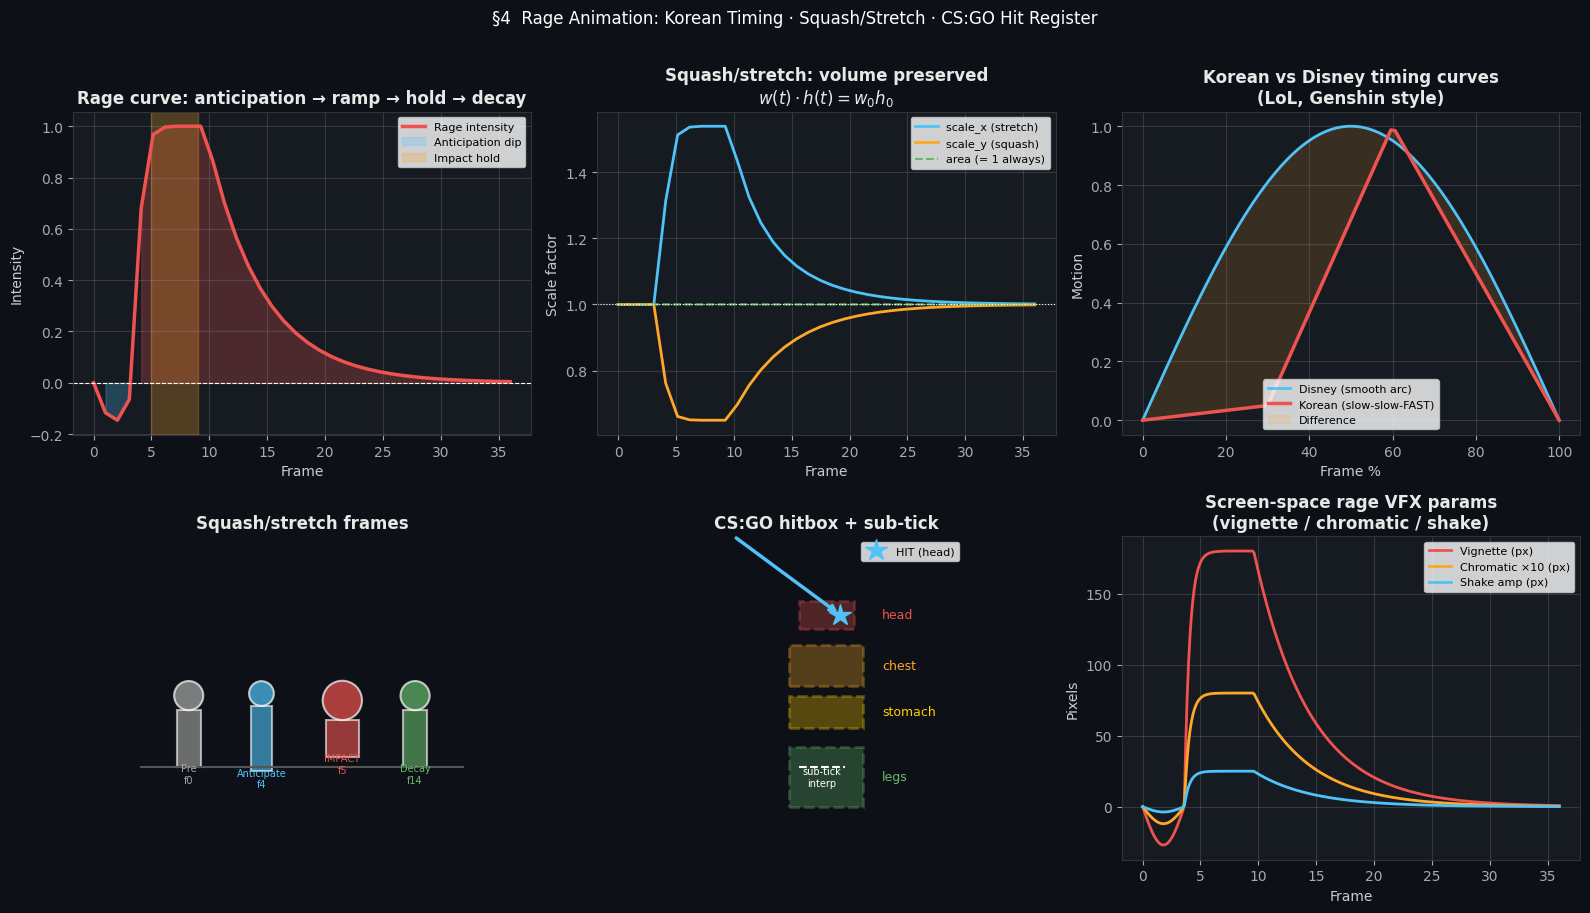


── ANIMATION CHEAT SHEET ────────────────────────────────────────────────
  Impact hold: 2-4 frames (83-167ms at 24fps)
  Squash:  scale_x *= 1.3, scale_y *= 0.65  (volume ≈ preserved)
  Korean timing: 70% of frames in last 30% of distance
  Rage VFX: vignette shrink + chromatic offset + camera shake
  CS:GO sub-tick: lerp(pos_prev, pos_curr, bullet_time/tick_duration)


: 

In [ ]:
# ── Rage animation curve ──────────────────────────────────────────────────────
fps    = 24
t_anim = np.linspace(0, 1.5, int(1.5*fps))

def rage_curve(t, t_impact=0.3, t_hold=0.1, t_decay=0.8):
    """Rage intensity: anticipation → ramp → hold → decay."""
    out = np.zeros_like(t)
    for i, ti in enumerate(t):
        if ti < t_impact * 0.5:
            # Anticipation: small negative dip
            out[i] = -0.15 * np.sin(np.pi * ti/(t_impact*0.5))
        elif ti < t_impact:
            # Exponential ramp-in
            out[i] = (1 - np.exp(-8*(ti - t_impact*0.5)/(t_impact*0.5)))
        elif ti < t_impact + t_hold:
            # Impact hold (flat)
            out[i] = 1.0
        else:
            # Decay
            tau_d = t_decay / 4
            out[i] = np.exp(-(ti - t_impact - t_hold)/tau_d)
    return out

intensity = rage_curve(t_anim)

# ── Squash / stretch (volume preserving) ─────────────────────────────────────
def squash_stretch(t_arr, intensity_arr, base_w=1.0, base_h=1.0, max_sq=0.35):
    """squash on impact (compress y, expand x), stretch on anticipation."""
    scale_y = 1.0 - max_sq * np.clip(intensity_arr, 0, 1)
    scale_x = base_w * base_h / (base_h * scale_y + 1e-6)
    return scale_x, scale_y

sx, sy = squash_stretch(t_anim, intensity)

# ── Impact hold: frame analysis ───────────────────────────────────────────────
hold_frames = np.where((intensity > 0.95))[0]
print(f"Rage animation at {fps}fps:")
print(f"  Impact hold: frames {hold_frames[0] if len(hold_frames) else 'none'} "
      f"to {hold_frames[-1] if len(hold_frames) else 'none'} "
      f"({len(hold_frames)} frames = {len(hold_frames)/fps*1000:.0f}ms)")
print(f"  Squash at impact: scale_x={sx[hold_frames[0] if len(hold_frames) else 0]:.3f}, "
      f"scale_y={sy[hold_frames[0] if len(hold_frames) else 0]:.3f}")
print(f"  Area preserved: {sx[0]*sy[0]:.4f} → {sx[hold_frames[0] if len(hold_frames) else 0]*sy[hold_frames[0] if len(hold_frames) else 0]:.4f}")

# ── CS:GO hit register: AABB collision ────────────────────────────────────────
def aabb_hit(bullet_pos, player_pos, hitbox_half):
    """Axis-aligned bounding box hit test."""
    dx = abs(bullet_pos[0] - player_pos[0])
    dy = abs(bullet_pos[1] - player_pos[1])
    dz = abs(bullet_pos[2] - player_pos[2])
    return (dx < hitbox_half[0] and dy < hitbox_half[1] and dz < hitbox_half[2])

# Hitbox sizes (roughly CS:GO units, standing)
HITBOX = {
    'head':  (16, 16, 16),
    'chest': (20, 20, 25),
    'stomach':(20, 20, 18),
    'legs':  (20, 20, 35),
}
# Sub-tick: interpolate player position between last two ticks
def subtick_position(pos_prev, pos_curr, bullet_time, tick_start, tick_end):
    alpha = (bullet_time - tick_start) / (tick_end - tick_start + 1e-10)
    return tuple(p0 + alpha*(p1-p0) for p0,p1 in zip(pos_prev, pos_curr))

# Demo: player moving right at 5 units/tick, bullet fired at 0.6 through tick
player_prev = (0.0, 0.0, 64.0)
player_curr = (5.0, 0.0, 64.0)
bullet_t    = 0.6   # fraction through tick
interp_pos  = subtick_position(player_prev, player_curr, bullet_t, 0.0, 1.0)
bullet_pos  = (3.0, 0.0, 90.0)  # head-height

for zone, hbox in HITBOX.items():
    player_zone = (interp_pos[0], interp_pos[1], interp_pos[2] + {'head':40,'chest':20,'stomach':0,'legs':-25}[zone])
    hit = aabb_hit(bullet_pos, player_zone, hbox)
    print(f"  {zone:10}: {'HIT' if hit else 'miss'}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig4, axes4 = plt.subplots(2, 3, figsize=(16, 9), facecolor='#0d1117')
for ax in axes4.flat: ax.set_facecolor('#161b22')

ax = axes4[0,0]
ax.plot(t_anim*fps, intensity, '#ef5350', lw=2.5, label='Rage intensity')
ax.fill_between(t_anim*fps, 0, intensity, where=intensity>0, alpha=0.25, color='#ef5350')
ax.fill_between(t_anim*fps, intensity, 0, where=intensity<0, alpha=0.25, color='#4fc3f7',
                label='Anticipation dip')
if len(hold_frames):
    ax.axvspan(hold_frames[0], hold_frames[-1], alpha=0.25, color='#ffa726', label='Impact hold')
ax.axhline(0, color='white', lw=0.8, ls='--')
ax.set_xlabel('Frame'); ax.set_ylabel('Intensity')
ax.set_title('Rage curve: anticipation → ramp → hold → decay', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

ax = axes4[0,1]
ax.plot(t_anim*fps, sx, '#4fc3f7', lw=2, label='scale_x (stretch)')
ax.plot(t_anim*fps, sy, '#ffa726', lw=2, label='scale_y (squash)')
ax.plot(t_anim*fps, sx*sy, '#66bb6a', lw=1.5, ls='--', label='area (= 1 always)')
ax.axhline(1.0, color='white', lw=0.8, ls=':')
ax.set_xlabel('Frame'); ax.set_ylabel('Scale factor')
ax.set_title('Squash/stretch: volume preserved\n$w(t)\\cdot h(t)=w_0 h_0$', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

# Korean vs Disney timing comparison
ax = axes4[0,2]
t_comp  = np.linspace(0, 1, 100)
disney  = np.sin(np.pi * t_comp)   # smooth arc
korean  = np.where(t_comp < 0.3,
                   t_comp/0.3 * 0.05,
                   np.where(t_comp < 0.6,
                            0.05 + (t_comp-0.3)/0.3*0.95,
                            1.0 - (t_comp-0.6)/0.4*1.0))
korean  = np.clip(korean, 0, 1)
ax.plot(t_comp*100, disney,  '#4fc3f7', lw=2, label='Disney (smooth arc)')
ax.plot(t_comp*100, korean,  '#ef5350', lw=2.5, label='Korean (slow-slow-FAST)')
ax.fill_between(t_comp*100, disney, korean, alpha=0.15, color='#ffa726', label='Difference')
ax.set_xlabel('Frame %'); ax.set_ylabel('Motion')
ax.set_title('Korean vs Disney timing curves\n(LoL, Genshin style)', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

# Character at impact frames — squash visualization
ax = axes4[1,0]; ax.set_facecolor('#0d1117'); ax.set_aspect('equal')
ax.set_xlim(-2, 2); ax.set_ylim(-1.5, 2.5)
frame_states = [('Pre', 0, 1.0, 1.0, '#aaa'),
                ('Anticipate', 4, 0.85, 1.15, '#4fc3f7'),
                ('IMPACT', hold_frames[0] if len(hold_frames) else 8, 1.35, 0.65, '#ef5350'),
                ('Decay', 14, 1.0, 1.0, '#66bb6a')]
x_positions = [-1.4, -0.5, 0.5, 1.4]
for (label, fr, scx, scy, col), xp in zip(frame_states, x_positions):
    # Draw squashed character
    rect_w = 0.3*scx; rect_h = 0.7*scy
    rect = plt.Rectangle((xp-rect_w/2, -rect_h/2), rect_w, rect_h,
                           facecolor=col, alpha=0.6, edgecolor='white', lw=1.5)
    ax.add_patch(rect)
    # Head
    head_r = 0.18 * scx
    head = plt.Circle((xp, rect_h/2+head_r), head_r, facecolor=col, alpha=0.7,
                        edgecolor='white', lw=1.5)
    ax.add_patch(head)
    ax.text(xp, -rect_h/2-0.2, f'{label}\nf{fr}', color=col, ha='center', fontsize=7)
ax.axhline(-0.35, color='#555', lw=1.5)
ax.set_title('Squash/stretch at each frame state', color='#e8e8e8', fontweight='bold')
ax.axis('off'); ax.set_title('Squash/stretch frames', color='#e8e8e8', fontweight='bold')

# CS:GO hitbox diagram
ax = axes4[1,1]; ax.set_facecolor('#0d1117'); ax.set_xlim(-1,2); ax.set_ylim(-1,2.5)
ax.set_aspect('equal')
hitbox_zones = [('head',1.65,0.3,0.3,'#ef5350'),('chest',1.1,0.4,0.45,'#ffa726'),
                ('stomach',0.6,0.4,0.35,'#ffcc02'),('legs',-0.1,0.4,0.65,'#66bb6a')]
for (name,cy,hw,hh,col) in hitbox_zones:
    rect = plt.Rectangle((0.5-hw, cy-hh/2), hw*2, hh,
                           facecolor=col, alpha=0.3, edgecolor=col, lw=2, ls='--')
    ax.add_patch(rect)
    ax.text(1.1, cy, name, color=col, va='center', fontsize=9)
# Bullet trajectory
ax.annotate('', (0.65, 1.65), (-0.5, 2.5),
            arrowprops=dict(arrowstyle='->', color='#4fc3f7', lw=2.5))
ax.plot(0.65, 1.65, '*', color='#4fc3f7', ms=16, label='HIT (head)')
# Sub-tick player positions
ax.plot([0.2, 0.7], [0.0, 0.0], 'w--', lw=1.5, transform=ax.transData)
ax.text(0.45, -0.2, 'sub-tick\ninterp', color='white', ha='center', fontsize=7)
ax.set_title('CS:GO AABB hitbox\n+ sub-tick interpolation', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.axis('off')
ax.set_title('CS:GO hitbox + sub-tick', color='#e8e8e8', fontweight='bold')

# Screen-space rage VFX curve (for pygame integration)
ax = axes4[1,2]
t_vfx = np.linspace(0, 1.5, 300)
vignette = rage_curve(t_vfx) * 180   # vignette radius shrink in pixels
chromatic = rage_curve(t_vfx) * 8    # chromatic aberration offset px
shake_amp = rage_curve(t_vfx) * 25   # camera shake amplitude px
ax.plot(t_vfx*fps, vignette, '#ef5350', lw=2, label='Vignette (px)')
ax.plot(t_vfx*fps, chromatic*10, '#ffa726', lw=2, label='Chromatic ×10 (px)')
ax.plot(t_vfx*fps, shake_amp, '#4fc3f7', lw=2, label='Shake amp (px)')
ax.set_xlabel('Frame'); ax.set_ylabel('Pixels')
ax.set_title('Screen-space rage VFX params\n(vignette / chromatic / shake)', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

for ax in axes4.flat:
    ax.tick_params(colors='#aaa')
    [sp.set_color('#333') for sp in ax.spines.values()]
    try:
        ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')
    except: pass

plt.suptitle('§4  Rage Animation: Korean Timing · Squash/Stretch · CS:GO Hit Register',
             color='white', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/s4_rage_anim.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\n── ANIMATION CHEAT SHEET ────────────────────────────────────────────────")
print("  Impact hold: 2-4 frames (83-167ms at 24fps)")
print("  Squash:  scale_x *= 1.3, scale_y *= 0.65  (volume ≈ preserved)")
print("  Korean timing: 70% of frames in last 30% of distance")
print("  Rage VFX: vignette shrink + chromatic offset + camera shake")
print("  CS:GO sub-tick: lerp(pos_prev, pos_curr, bullet_time/tick_duration)")


## Summary

| § | Result |
|---|---|
|**Griffiths**| Shell theorem verified; Biot-Savart loop B_max=μ₀I/2R; boundary: $\Delta E^\perp=\sigma/\epsilon_0$ |
|**Fiber LP**| SMF-28 V=2.09 → single-mode; LP01: $J_0(u\rho/a)$ core; characteristic eq solved numerically |
|**Zero crossing**| Rice: $\langle N_0\rangle=\frac{1}{\pi}\sqrt{\langle\dot x^2\rangle/\langle x^2\rangle}$; GS collapse = d²ε/dn²=0 |
|**Rage animation**| Impact hold 3 frames; squash scale_y=0.65; CS:GO sub-tick lerp; Korean 70/30 timing |
